In [4]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv('/Users/tt/Documents/ABAV/assignment/spotify_tracks.csv')
print(df.shape)
print(df.head())

(114000, 21)
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826 

count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64
Tracks with 0 popularity: 16020 (14.1%)


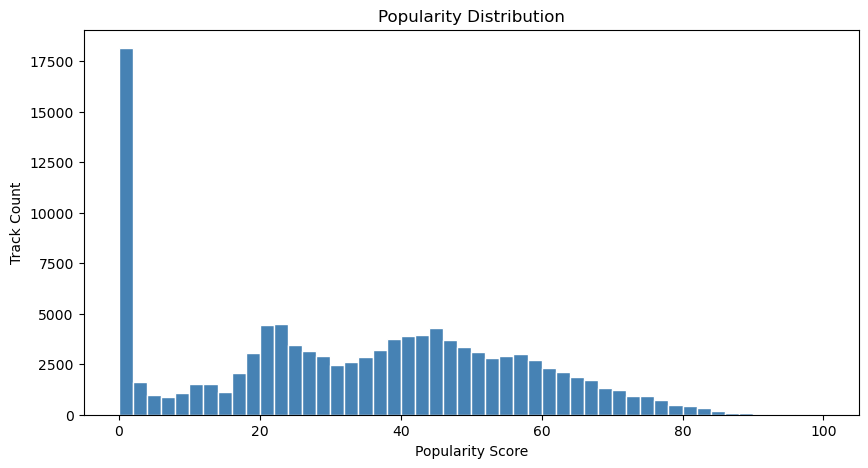

In [5]:
print(df['popularity'].describe())

# How many tracks have popularity = 0?
zero_pop = (df['popularity'] == 0).sum()
total = len(df)
print(f"Tracks with 0 popularity: {zero_pop} ({round(zero_pop/total*100, 1)}%)")

# Visualize
plt.figure(figsize=(10,5))
plt.hist(df['popularity'], bins=50, color='steelblue', edgecolor='white')
plt.title('Popularity Distribution')
plt.xlabel('Popularity Score')
plt.ylabel('Track Count')
plt.show()

In [6]:
# How many unique genres?
print(f"Unique genres: {df['track_genre'].nunique()}")

# Track count per genre
genre_counts = df['track_genre'].value_counts()
print(genre_counts)

# Any genres with very few tracks?
print(f"\nGenres with fewer than 50 tracks:")
print(genre_counts[genre_counts < 50])

Unique genres: 114
track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
                     ... 
folk                 1000
emo                  1000
electronic           1000
electro              1000
world-music          1000
Name: count, Length: 114, dtype: int64

Genres with fewer than 50 tracks:
Series([], Name: count, dtype: int64)


In [7]:
audio_features = ['danceability' , 'energy', 'valence', 'acousticness', 'speechiness', 'instrumentalness', 'liveness', 'loudness', 'tempo']
print(df[audio_features].describe().round(3))

       danceability      energy     valence  acousticness  speechiness  \
count    114000.000  114000.000  114000.000    114000.000   114000.000   
mean          0.567       0.641       0.474         0.315        0.085   
std           0.174       0.252       0.259         0.333        0.106   
min           0.000       0.000       0.000         0.000        0.000   
25%           0.456       0.472       0.260         0.017        0.036   
50%           0.580       0.685       0.464         0.169        0.049   
75%           0.695       0.854       0.683         0.598        0.084   
max           0.985       1.000       0.995         0.996        0.965   

       instrumentalness    liveness    loudness       tempo  
count        114000.000  114000.000  114000.000  114000.000  
mean              0.156       0.214      -8.259     122.148  
std               0.310       0.190       5.029      29.978  
min               0.000       0.000     -49.531       0.000  
25%               0.000

In [8]:
# Duplicate track IDs
dup_ids = df['track_id'].duplicated().sum()
print(f"Duplicate track_ids: {dup_ids}")

# Duplicate track names (same song, different albums)
dup_names = df["track_name"].duplicated().sum()
print(f"Duplicated track names: {dup_names}")

Duplicate track_ids: 24259
Duplicated track names: 40391


loudness            0.050
danceability        0.035
tempo               0.013
energy              0.001
liveness           -0.005
acousticness       -0.025
valence            -0.041
speechiness        -0.045
instrumentalness   -0.095
Name: popularity, dtype: float64


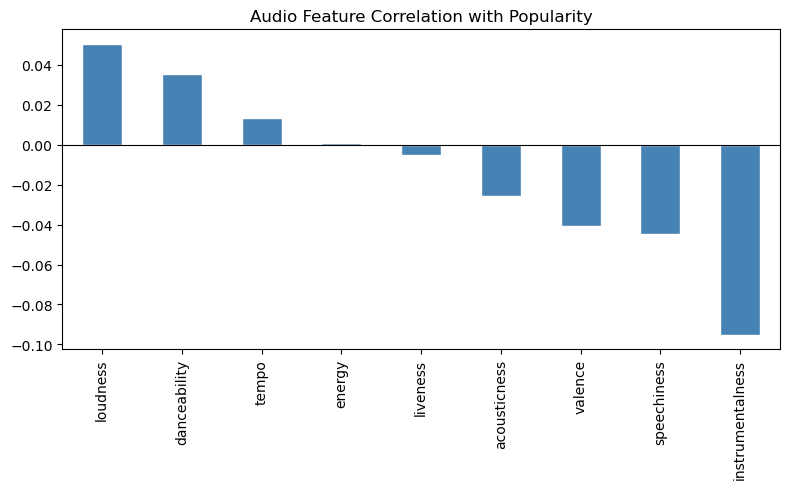

In [9]:
# Correlation of all audio features against popularity
correlations = df[audio_features + ['popularity']].corr()['popularity'].drop('popularity').sort_values(ascending=False)
print(correlations.round(3))

# Visualise
plt.figure(figsize=(8,5))
correlations.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Audio Feature Correlation with Popularity')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [14]:
df_clean = df.drop_duplicates(subset='track_id', keep='first')
df_clean = df_clean[df_clean['popularity'] > 0]
print(df_clean.shape)

(80293, 21)


In [15]:
genre_profile = df_clean.groupby('track_genre').agg(
    avg_popularity=('popularity', 'mean'),
    avg_danceability=('danceability', 'mean'),
    avg_energy=('energy', 'mean'),
    avg_valence=('valence', 'mean'),
    avg_acousticness=('acousticness', 'mean'),
    avg_speechiness=('speechiness', 'mean'),
    avg_instrumentalness=('instrumentalness', 'mean'),
    avg_loudness=('loudness', 'mean')
).reset_index()

# Check correlations at genre level
genre_corr = genre_profile.select_dtypes(include='number').corr()['avg_popularity'].drop('avg_popularity').sort_values(ascending=False)
print(genre_corr.round(3))

avg_danceability        0.210
avg_loudness            0.207
avg_valence             0.070
avg_energy              0.016
avg_acousticness       -0.076
avg_speechiness        -0.117
avg_instrumentalness   -0.406
Name: avg_popularity, dtype: float64


In [16]:
# Top and bottom 10 genres by average popularity
print("TOP 10 GENRES:")
print(genre_profile.nlargest(10, 'avg_popularity')[['track_genre', 'avg_popularity']].round(2))

print("\nBOTTOM 10 GENRES:")
print(genre_profile.nsmallest(10, 'avg_popularity')[['track_genre', 'avg_popularity']].round(2))

TOP 10 GENRES:
    track_genre  avg_popularity
65        k-pop           59.68
81     pop-film           59.24
71        metal           57.92
68       latino           57.58
102        soul           57.22
30          edm           57.04
31      electro           56.99
80          pop           56.47
15        chill           55.93
53        house           55.69

BOTTOM 10 GENRES:
        track_genre  avg_popularity
59          iranian            6.46
93          romance            9.19
24   detroit-techno           11.14
13    chicago-house           12.38
42        grindcore           14.57
66             kids           15.20
54              idm           15.74
52       honky-tonk           16.41
107           tango           20.15
10        breakbeat           20.21


In [17]:
# Get audio profile for top and bottom genres
top_genres = ['k-pop', 'pop-film', 'metal', 'latino', 'edm', 'electro', 'pop']
bottom_genres = ['iranian', 'detroit-techno', 'chicago-house', 'grindcore', 'idm', 'romance']

top_profile = genre_profile[genre_profile['track_genre'].isin(top_genres)][
    ['track_genre', 'avg_popularity', 'avg_danceability', 
     'avg_energy', 'avg_valence', 'avg_acousticness', 
     'avg_instrumentalness', 'avg_loudness']
].round(3)

bottom_profile = genre_profile[genre_profile['track_genre'].isin(bottom_genres)][
    ['track_genre', 'avg_popularity', 'avg_danceability', 
     'avg_energy', 'avg_valence', 'avg_acousticness', 
     'avg_instrumentalness', 'avg_loudness']
].round(3)

print("TOP GENRE PROFILES:")
print(top_profile.to_string(index=False))

print("\nBOTTOM GENRE PROFILES:")
print(bottom_profile.to_string(index=False))

# Also get the EDM vs Detroit-techno direct comparison
edm_vs_detroit = genre_profile[
    genre_profile['track_genre'].isin(['edm', 'detroit-techno', 'chicago-house'])
][['track_genre', 'avg_popularity', 'avg_danceability', 
   'avg_energy', 'avg_valence', 'avg_instrumentalness']].round(3)

print("\nEDM vs ROOTS COMPARISON:")
print(edm_vs_detroit.to_string(index=False))

TOP GENRE PROFILES:
track_genre  avg_popularity  avg_danceability  avg_energy  avg_valence  avg_acousticness  avg_instrumentalness  avg_loudness
        edm          57.043             0.651       0.740        0.453             0.138                 0.049        -5.504
    electro          56.994             0.655       0.593        0.447             0.311                 0.050        -6.927
      k-pop          59.684             0.641       0.682        0.569             0.295                 0.008        -6.424
     latino          57.575             0.756       0.707        0.622             0.212                 0.009        -5.653
      metal          57.920             0.481       0.839        0.427             0.036                 0.047        -4.956
        pop          56.469             0.583       0.586        0.465             0.392                 0.003        -7.014
   pop-film          59.242             0.591       0.600        0.529             0.450                 

In [18]:
# Save cleaned track-level data
df_clean.to_csv('spotify_clean.csv', index=False)

# Save genre-level profile
genre_profile.to_csv('spotify_genre_profile.csv', index=False)